Carregando imagens e dividindo dataset...
Found 200 files belonging to 2 classes.
Using 160 files for training.
Found 200 files belonging to 2 classes.
Using 40 files for validation.

--- TREINANDO A CNN SIMPLES ---
Epoch 1/10


C:\Users\guili\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5000 - loss: 0.6190 - val_accuracy: 0.5000 - val_loss: 0.4566
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8000 - loss: 0.3938 - val_accuracy: 0.9750 - val_loss: 0.3520
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9875 - loss: 0.3462 - val_accuracy: 1.0000 - val_loss: 0.3420
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.3400 - val_accuracy: 1.0000 - val_loss: 0.3383
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9937 - loss: 0.3377 - val_accuracy: 1.0000 - val_loss: 0.3367
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.3355 - val_accuracy: 1.0000 - val_loss: 0.3339
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.3322 - val_accuracy: 1.0000 - val_loss: 0.3309
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - loss: 0.3298 - val_accuracy: 1.0000 - val_loss: 0.

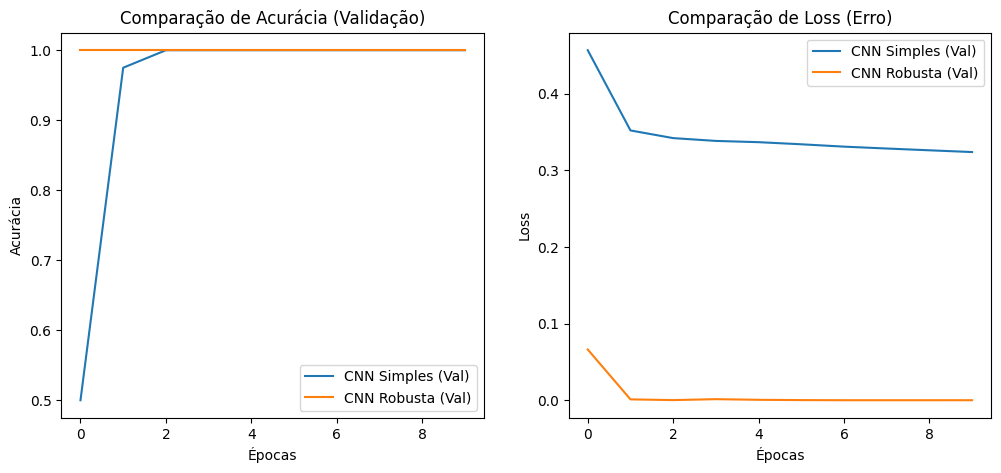

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. PREPARAÇÃO DO DATASET (Treino, Validação e Teste)
# ==========================================
print("Carregando imagens e dividindo dataset...")
batch_size = 16
img_height = 64
img_width = 64
data_dir = '../dataset'

# Carregando 80% para treino
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# Carregando 20% para validação/teste
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# Normalizando os pixels para ficar entre 0 e 1 (Acelera a convergência)
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# ==========================================
# 2. ARQUITETURA 1: CNN SIMPLES (Baseline)
# ==========================================
# Uma rede intencionalmente mais básica para servir de comparação
cnn_simples = models.Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu', input_shape=(img_height, img_width, 3)),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(64, activation='relu'),
  layers.Dense(1, activation='sigmoid') # 1 neurônio de saída (0 = Limpa, 1 = Obstruída)
], name="CNN_Simples")

cnn_simples.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ==========================================
# 3. ARQUITETURA 2: CNN ROBUSTA (Com Regularização)
# ==========================================
# Adicionamos Dropout para evitar overfitting e mais camadas convolucionais
cnn_robusta = models.Sequential([
  layers.Conv2D(32, 3, padding='same', activation='relu', input_shape=(img_height, img_width, 3)),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dropout(0.5), # Desliga 50% dos neurônios no treino para forçar a rede a generalizar
  layers.Dense(1, activation='sigmoid')
], name="CNN_Robusta")

cnn_robusta.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ==========================================
# 4. TREINAMENTO (Treinando do zero, sem pesos prontos)
# ==========================================
epochs = 10
print("\n--- TREINANDO A CNN SIMPLES ---")
history_simples = cnn_simples.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)

print("\n--- TREINANDO A CNN ROBUSTA ---")
history_robusta = cnn_robusta.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)

# ==========================================
# 5. COMPARAÇÃO DE DESEMPENHO E MÉTRICAS
# ==========================================
acc_simples = history_simples.history['val_accuracy'][-1]
acc_robusta = history_robusta.history['val_accuracy'][-1]

print(f"\n RESULTADO FINAL :")
print(f"Acurácia CNN Simples: {acc_simples * 100:.2f}%")
print(f"Acurácia CNN Robusta: {acc_robusta * 100:.2f}%")

# Plotando os gráficos (Tire print disso para o seu README!)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_simples.history['val_accuracy'], label='CNN Simples (Val)')
plt.plot(history_robusta.history['val_accuracy'], label='CNN Robusta (Val)')
plt.title('Comparação de Acurácia (Validação)')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_simples.history['val_loss'], label='CNN Simples (Val)')
plt.plot(history_robusta.history['val_loss'], label='CNN Robusta (Val)')
plt.title('Comparação de Loss (Erro)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Salvando os pesos do melhor modelo para usar no Streamlit depois
cnn_robusta.save('modelo_acv_robusto.h5')